## Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
import plotly.express as px
import re
import pickle
import gzip
import pandas as pd
import sys
sys.path.append('/Users/chenwei/Desktop/Github/ViDa') 


import imp, vida.data_processing.strandReorder
imp.reload(vida.data_processing.strandReorder)
from vida.data_processing.strandReorder import *

# import imp, vida.data_processing.utils
# imp.reload(vida.data_processing.utils)
# from vida.data_processing.utils import *

import imp, vida.adjmat.dp2adj
imp.reload(vida.adjmat.dp2adj)
from vida.adjmat.dp2adj import *

import imp, vida.data_processing.comp_time
imp.reload(vida.data_processing.comp_time)
from vida.data_processing.comp_time import *


/var/folders/z9/3zs_cg3x09n1q9fmthyx2x600000gn/T/ipykernel_6202/4132767655.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp, vida.data_processing.strandReorder


In [2]:
def loadTimeData(datafile):
    inpath = f'../data/post_data/{datafile}/preprocess_{datafile}.npz'
    loaded_data = np.load(inpath, allow_pickle=True)
    trans_time = loaded_data["trans_time"]
    
    inpath2 = f'../data/post_data/{datafile}/time_{datafile}.npz'
    loaded_data2 = np.load(inpath2, allow_pickle=True)
    trj_id = loaded_data2['trj_id']

    rxnTimes = trans_time[trj_id]
    ids = np.arange(rxnTimes.shape[0])
    # sortTimes = np.sort(rxnTimes)[::-1]
    # sortIDs = ids[np.argsort(rxnTimes)[::-1]]
        
    return rxnTimes, ids



def loadStateData(datafile):
    
    inpath = f'../data/post_data/{datafile}/{datafile}.pkl.gz'
    with gzip.open(inpath, 'rb') as file:
        loaded_data = pickle.load(file)
    trajs_states = loaded_data['trajs_states']
    trajs_shortnames = loaded_data['trajs_shortnames']
        
    return trajs_states, trajs_shortnames



def timeCDF(datafile, rxnTimes):
    
    sort_time = np.sort(rxnTimes)
    cumulative_fraction = np.arange(1, len(sort_time) + 1) / len(sort_time)

    plt.plot(sort_time, cumulative_fraction, '-')
    plt.title(f'CDF of Reaction Times {datafile}')
    plt.xlabel('Reaction Time (s)')
    plt.ylabel('Cumulative Fraction')
    plt.xscale('log')
    plt.grid(True)
    plt.show()

    print('Max reaction time:', np.max(rxnTimes), 'seconds')
    print('Min reaction time:', np.min(rxnTimes), 'seconds')
    print('Average reaction time:', np.mean(rxnTimes), 'seconds')
    print('Median reaction time:', np.median(rxnTimes), 'seconds')
    # thres = np.float64(1e-2)
    # print(f'Number of reaction slower than {thres}:', np.where(rxnTimes > thres)[0].shape[0])
    # print(f'Number of reaction faster than {thres}:', np.where(rxnTimes < thres)[0].shape[0])


## Machinek-Perfect

### Time distribution sort

In [3]:
datafile = 'Machinek-PRF'
rxnTimes, ids = loadTimeData(datafile)

In [70]:
# fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs], log_y=True)
# # fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs])

# # plot a horizontal line for the average time
# fig.add_hline(y=np.mean(rxnTimes), line_dash="dot", line_color="red")
# fig.add_hline(y=1e-2, line_dash="dot", line_color="green")

# fig.show()

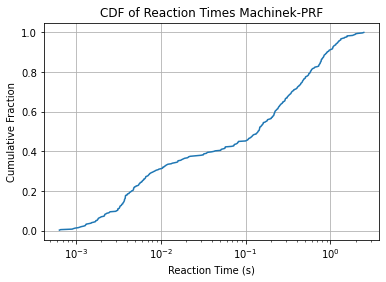

Max reaction time: 2.4719820372770687 seconds
Min reaction time: 0.0006404025694753318 seconds
Average reaction time: 0.31602669386911414 seconds
Median reaction time: 0.14070118945995877 seconds


In [4]:
timeCDF(datafile, rxnTimes)

### Statistics

In [5]:
trajs_states, trajs_shortnames = loadStateData(datafile)

In [6]:
mismatchIntraj = np.zeros(len(trajs_shortnames), dtype=int)

for i, shortnames in enumerate(trajs_shortnames):
    
    for j, name in enumerate(shortnames):
        if name == 'inv+sub+incb':
            inv, sub, _ = trajs_states[i][j].split('+')
            
            # identify the mismatched strand
            if '))))' in sub[0:5] and '((((' in inv:
                # if sub[0] == ')' or sub[1] == ')' or sub[2] == ')':
                mismatchIntraj[i] = 1 
                
                
                # if i in [275, 117, 287, 270, 259]:
                #     print(i)
                #     print(trajs_states[i][j])
                #     print(sub, inv)
                # break
            
        if name == 'incb+sub+inv': 
            _, sub, inv = trajs_states[i][j].split('+') 
            
            # identify the mismatched strand
            if '((((' in sub[0:5] and '))))' in inv:
                mismatchIntraj[i] = 1 
                break   
    

In [7]:
traj_mismatch = np.where(mismatchIntraj == 1)[0]
traj_mismatch.shape[0], traj_mismatch

(265,
 array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         15,  17,  19,  20,  21,  22,  25,  26,  27,  28,  29,  31,  32,
         33,  34,  35,  36,  37,  39,  40,  41,  42,  43,  44,  45,  48,
         49,  50,  51,  53,  54,  56,  58,  59,  60,  65,  66,  69,  71,
         72,  74,  75,  76,  77,  78,  80,  81,  82,  86,  88,  89,  91,
         92,  93,  94,  96, 100, 102, 103, 106, 107, 108, 111, 113, 115,
        116, 117, 118, 119, 120, 122, 123, 125, 129, 133, 135, 136, 138,
        141, 143, 146, 147, 149, 150, 151, 153, 154, 157, 158, 159, 160,
        162, 165, 166, 167, 168, 169, 171, 172, 173, 174, 176, 178, 180,
        181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 194, 196, 197,
        198, 199, 200, 202, 203, 204, 205, 209, 212, 213, 214, 215, 218,
        219, 220, 222, 223, 224, 227, 228, 230, 231, 233, 234, 235, 236,
        238, 239, 241, 242, 244, 245, 248, 250, 251, 253, 258, 259, 260,
        262, 263, 265, 266, 268, 269, 270, 27

In [8]:
traj_no_mismatch = np.where(mismatchIntraj == 0)[0]

traj_no_mismatch.shape[0], traj_no_mismatch

(135,
 array([  0,  14,  16,  18,  23,  24,  30,  38,  46,  47,  52,  55,  57,
         61,  62,  63,  64,  67,  68,  70,  73,  79,  83,  84,  85,  87,
         90,  95,  97,  98,  99, 101, 104, 105, 109, 110, 112, 114, 121,
        124, 126, 127, 128, 130, 131, 132, 134, 137, 139, 140, 142, 144,
        145, 148, 152, 155, 156, 161, 163, 164, 170, 175, 177, 179, 183,
        184, 193, 195, 201, 206, 207, 208, 210, 211, 216, 217, 221, 225,
        226, 229, 232, 237, 240, 243, 246, 247, 249, 252, 254, 255, 256,
        257, 261, 264, 267, 271, 273, 274, 280, 282, 284, 286, 294, 302,
        304, 306, 308, 313, 314, 316, 317, 325, 326, 331, 333, 334, 335,
        338, 348, 350, 357, 358, 359, 361, 363, 364, 365, 373, 374, 376,
        379, 380, 381, 382, 397]))

In [10]:
print('Average reaction time for trajectories with mismatch:', np.mean(rxnTimes[traj_mismatch]), 'seconds') 
print('Average reaction time for trajectories without mismatch:', np.mean(rxnTimes[traj_no_mismatch]), 'seconds')

Average reaction time for trajectories with mismatch: 0.4744173482421933 seconds
Average reaction time for trajectories without mismatch: 0.005111705655291973 seconds


In [129]:
# np.sort(rxn_times[traj_mismatch])[:10], traj_mismatch[np.argsort(rxn_times[traj_mismatch])[:5]]

In [11]:
# Count for hairpins in Non-mismatched reactions
hairpinInmatch = np.zeros(len(traj_no_mismatch), dtype=int)

for i, idx in enumerate(traj_no_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub inv':
            _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
    

In [12]:
print(f'{np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-mismatched reactions')

118 hairpins in 135 Non-mismatched reactions


In [13]:
print('The index of Non-mismatched reactions with hairpins:')
hp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==1)[0]]
nohp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==0)[0]]
hp_nonmismatch_index, nohp_nonmismatch_index

The index of Non-mismatched reactions with hairpins:


(array([  0,  14,  16,  18,  23,  24,  30,  46,  47,  52,  55,  57,  61,
         63,  64,  67,  68,  70,  73,  83,  84,  85,  87,  95,  97,  98,
         99, 101, 104, 105, 109, 110, 112, 114, 121, 126, 127, 128, 132,
        134, 137, 139, 140, 142, 144, 145, 148, 152, 155, 156, 163, 164,
        170, 175, 177, 179, 183, 184, 195, 201, 206, 207, 208, 210, 211,
        216, 217, 221, 225, 226, 232, 240, 243, 246, 247, 252, 254, 255,
        256, 257, 261, 267, 273, 274, 280, 282, 284, 286, 294, 302, 304,
        306, 308, 314, 316, 317, 325, 331, 333, 334, 335, 338, 348, 350,
        357, 358, 359, 361, 363, 364, 373, 374, 376, 379, 380, 381, 382,
        397]),
 array([ 38,  62,  79,  90, 124, 130, 131, 161, 193, 229, 237, 249, 264,
        271, 313, 326, 365]))

In [15]:
print('The overall average time of Non-mismatched reactions:')
print(np.mean(rxnTimes[traj_no_mismatch]))
print()
print('The average time of Non-mismatched reactions with Hairpins:')
print(np.mean(rxnTimes[hp_nonmismatch_index]))
print()
print('The average time of Non-mismatched reactions without Hairpins:')
print(np.mean(rxnTimes[traj_no_mismatch[np.where(hairpinInmatch==0)[0]]]))


The overall average time of Non-mismatched reactions:
0.005111705655291973

The average time of Non-mismatched reactions with Hairpins:
0.005217078907847982

The average time of Non-mismatched reactions without Hairpins:
0.004380291314020861


In [16]:
# Count for hairpins in Mismatched reactions

hairpinInmismatch = np.zeros(len(traj_mismatch), dtype=int)

for i, idx in enumerate(traj_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub inv':
                _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
                
                if '(((' in inv[6:17] and ')))' in inv[6:17]:
                    hairpinInmismatch[i] = 1
                    break

In [17]:
print(f'{np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-mismatched reactions')

265 hairpins in 265 Non-mismatched reactions


In [18]:
print('The index of Mismatched reactions with hairpins:')
hp_mismatch_index = traj_mismatch[np.where(hairpinInmismatch==1)[0]]
hp_mismatch_index

The index of Mismatched reactions with hairpins:


array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        15,  17,  19,  20,  21,  22,  25,  26,  27,  28,  29,  31,  32,
        33,  34,  35,  36,  37,  39,  40,  41,  42,  43,  44,  45,  48,
        49,  50,  51,  53,  54,  56,  58,  59,  60,  65,  66,  69,  71,
        72,  74,  75,  76,  77,  78,  80,  81,  82,  86,  88,  89,  91,
        92,  93,  94,  96, 100, 102, 103, 106, 107, 108, 111, 113, 115,
       116, 117, 118, 119, 120, 122, 123, 125, 129, 133, 135, 136, 138,
       141, 143, 146, 147, 149, 150, 151, 153, 154, 157, 158, 159, 160,
       162, 165, 166, 167, 168, 169, 171, 172, 173, 174, 176, 178, 180,
       181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 194, 196, 197,
       198, 199, 200, 202, 203, 204, 205, 209, 212, 213, 214, 215, 218,
       219, 220, 222, 223, 224, 227, 228, 230, 231, 233, 234, 235, 236,
       238, 239, 241, 242, 244, 245, 248, 250, 251, 253, 258, 259, 260,
       262, 263, 265, 266, 268, 269, 270, 272, 275, 276, 277, 27

In [19]:
print('The average time of Mismatched reactions with hairpins:', np.mean(rxnTimes[hp_mismatch_index]))

The average time of Mismatched reactions with hairpins: 0.4744173482421933


### Detailed plots

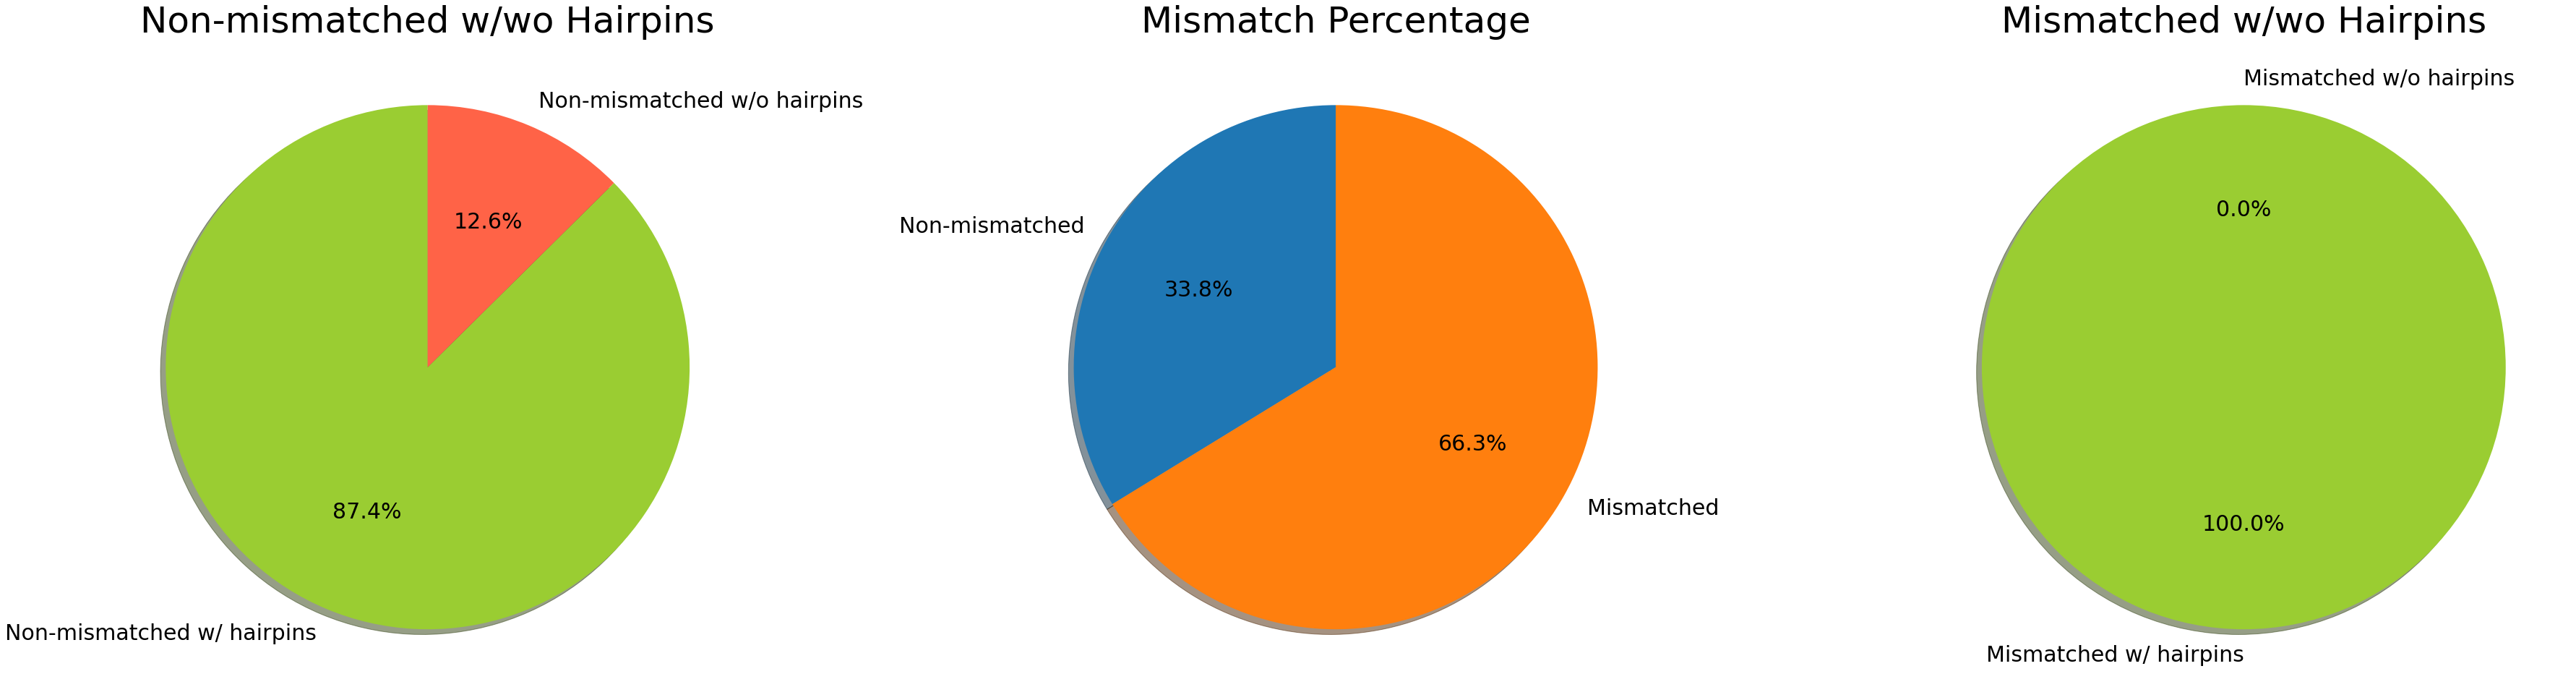

                                         265 hairpins in 265 Non-mismatched reactions
                                         118 hairpins in 135 Non-mismatched reactions


In [20]:
import matplotlib.pyplot as plt

# Data for the first pie chart
labels1 = ['Non-mismatched', 'Mismatched']
sizes1 = [traj_no_mismatch.shape[0], traj_mismatch.shape[0]]

# Data for the second pie chart
label2 = ['Non-mismatched w/ hairpins', 'Non-mismatched w/o hairpins']
size2 = [hp_nonmismatch_index.shape[0], traj_no_mismatch.shape[0] - hp_nonmismatch_index.shape[0]]

# Data for the third pie chart
label3 = ['Mismatched w/ hairpins', 'Mismatched w/o hairpins']
size3 = [hp_mismatch_index.shape[0], traj_mismatch.shape[0] - hp_mismatch_index.shape[0]]


fig, ax = plt.subplots(1, 3, figsize=(50, 30)) 
# First pie chart
color_hairpin = ['yellowgreen', 'tomato']
ax[0].pie(size2, labels=label2, autopct='%1.1f%%', shadow=True, startangle=90,  colors=color_hairpin, textprops={'fontsize': 30})
ax[0].set_title('Non-mismatched w/wo Hairpins')
ax[0].title.set_size(50)
# Second pie chart
ax[1].pie(sizes1, labels=labels1, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 30})
ax[1].set_title('Mismatch Percentage')
# title size
ax[1].title.set_size(50)
# Third pie chart
ax[2].pie(size3, labels=label3, autopct='%1.1f%%', shadow=True, startangle=90, colors=color_hairpin, textprops={'fontsize': 30})
ax[2].set_title('Mismatched w/wo Hairpins')
ax[2].title.set_size(50)
# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

print(f'                                         {np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-mismatched reactions')
print(f'                                         {np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-mismatched reactions')


/var/folders/z9/3zs_cg3x09n1q9fmthyx2x600000gn/T/ipykernel_6202/2646572047.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(time_names, fontsize=15)


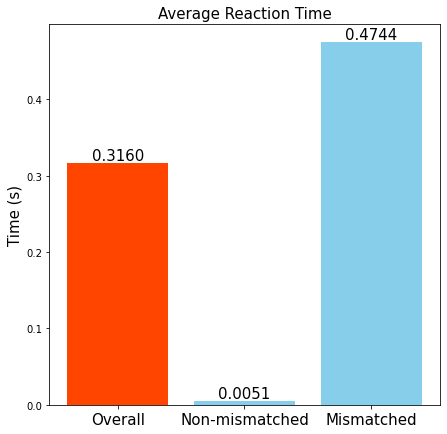

In [21]:
fig, ax = plt.subplots(figsize=(7,7))
time_names = ['Overall', 'Non-mismatched', 'Mismatched']
bar_colors = ['orangered', 'skyblue', 'skyblue']
average_times = [np.mean(rxnTimes), np.mean(rxnTimes[traj_no_mismatch]), np.mean(rxnTimes[traj_mismatch])]
bars = ax.bar(time_names, average_times, color=bar_colors)
ax.set_title('Average Reaction Time', fontsize=15)
ax.set_ylabel('Time (s)', fontsize=15)
ax.set_xticklabels(time_names, fontsize=15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom', fontsize=15)


In [22]:
print("Conclusion: \n Hairpin structures severs as two roles:\n \
1. If hairpins form first, then they will prevent the reaction to form mismatches, speeding up the reaction.\n \
2. If mismatches happen first, then hairpins will serve as 'escape route', to help reaction trajectories \n \
   escape from the kinetic traps towards the final state. \n") 

Conclusion: 
 Hairpin structures severs as two roles:
 1. If hairpins form first, then they will prevent the reaction to form mismatches, speeding up the reaction.
 2. If mismatches happen first, then hairpins will serve as 'escape route', to help reaction trajectories 
    escape from the kinetic traps towards the final state. 



### PCA Variance

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [28]:
# Load embeddings

datafile='Machinek-PRF-trunc'

TNAME = '24-0324-0120'
CKPT = 'checkpoint_epoch_39'
# CKPT = 'model'

inpath5 = f'../data/post_data/{datafile}/model_config/{TNAME}/embed_{CKPT}_Machinek-PRF.npz'
loaded_data5 = np.load(inpath5, allow_pickle=True)
embeddings = loaded_data5['embeddings']
embeddings.max(), embeddings.min(), embeddings.mean(), embeddings.std()

(18.535126, -15.465101, -0.100150794, 2.7371447)

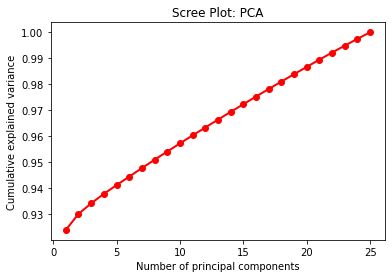

[0.9238547  0.93002415 0.9340898  0.93775463 0.9411008  0.94438595
 0.9476529  0.950886   0.95405656 0.9571719  0.9602631  0.9633008
 0.96633756 0.96931356 0.9722773  0.9752209  0.97813433 0.981011
 0.98385376 0.98666483 0.9894405  0.99219406 0.9948486  0.997461
 1.        ]


In [29]:
cm = PCA(n_components=25)
cm.fit(embeddings)

PC_values = np.arange(cm.n_components_) + 1
plt.plot(PC_values, np.cumsum(cm.explained_variance_ratio_), 'ro-', linewidth=2)
plt.title('Scree Plot: PCA')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance');
# plt.xticks(np.arange(0, data_embed.shape[-1]+1, 1))

plt.show()

print(np.cumsum(cm.explained_variance_ratio_))

## Machinek-MM14

### Time distribution plot

In [25]:
datafile = 'Machinek-Mismatch14'
rxnTimes, ids = loadTimeData(datafile)

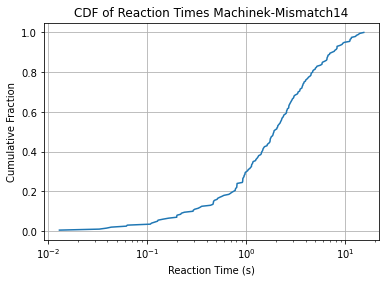

Max reaction time: 15.388087213733092 seconds
Min reaction time: 0.013110345685328458 seconds
Average reaction time: 3.013855969181078 seconds
Median reaction time: 1.9128896734942349 seconds


In [26]:
timeCDF(datafile, rxnTimes)

## Machinek-MM14C2T

In [27]:
datafile = 'Machinek-Mismatch14C2T'
rxnTimes, ids = loadTimeData(datafile)

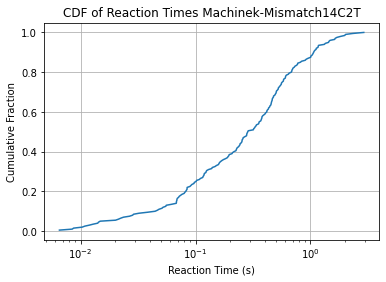

Max reaction time: 2.9118061595676443 seconds
Min reaction time: 0.0065370445307098 seconds
Average reaction time: 0.4420450385714598 seconds
Median reaction time: 0.28596644443911623 seconds


In [28]:
timeCDF(datafile, rxnTimes)

## Machinek-MM10

In [29]:
datafile = 'Machinek-Mismatch10'
rxnTimes, ids = loadTimeData(datafile)

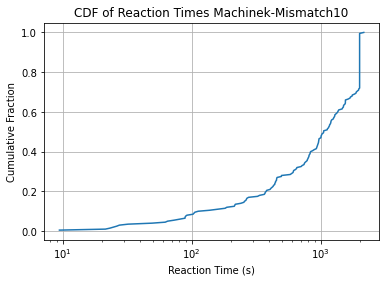

Max reaction time: 2154.546582464505 seconds
Min reaction time: 9.424768510880185 seconds
Average reaction time: 1133.9511061469436 seconds
Median reaction time: 1053.129848169549 seconds


In [30]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2

In [31]:
datafile = 'Machinek-Mismatch2'
rxnTimes, ids = loadTimeData(datafile)

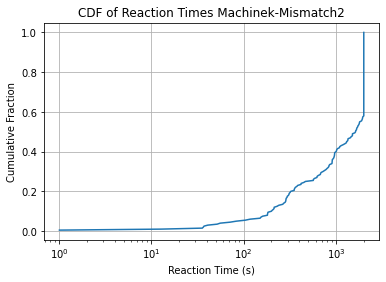

Max reaction time: 1999.9997478039215 seconds
Min reaction time: 1.0101684277319627 seconds
Average reaction time: 1293.6079721516098 seconds
Median reaction time: 1631.2280290475103 seconds


In [32]:
timeCDF(datafile, rxnTimes)